In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.chdir('/home/jovyan/kuratov/data/test_time_gd/')

import torch

from transformers import GPT2Config, GPT2LMHeadModel

from kv_dataset_utils import create_tokenizer

In [3]:
from grad_memgpt import GradMemGPT

In [4]:
# create tokenizer
tokenizer = create_tokenizer()

In [8]:
from kv_dataset_utils import generate_sequence

num_kv_pairs = 2
k_length = 4
v_length = 4
n_segments = 4
min_segment_len = 32
max_segment_len = 64

sample = generate_sequence(num_kv_pairs, k_length, v_length, n_segments, min_segment_len, max_segment_len)
sample

{'kv_pairs': ['!7nBT:baOr!', '!0uck:BPPl!'],
 'segment_ids_to_kv_ids': {0: [], 1: [], 2: [], 3: [0, 1]},
 'context': 'biMzLf551LEpwkFkQB615bhkL924rB835o7oZ|RGd8NSESI0GgZisBQBQRmeCTSNU9Y69UlQZnDNkphLyo7oC3ejW7DarOpGV4fw|y6WyrllaahxZh3BHS5WYEvcyfg5eGE99B3IAf0uLF5n3xdXjO|Vkq!0uck:BPPl!3gjOuRDoSyPLyrX!7nBT:baOr!iwexzs3zaP1c3vLI|',
 'query': '?!0uck:',
 'input_sequence': 'biMzLf551LEpwkFkQB615bhkL924rB835o7oZ|RGd8NSESI0GgZisBQBQRmeCTSNU9Y69UlQZnDNkphLyo7oC3ejW7DarOpGV4fw|y6WyrllaahxZh3BHS5WYEvcyfg5eGE99B3IAf0uLF5n3xdXjO|Vkq!0uck:BPPl!3gjOuRDoSyPLyrX!7nBT:baOr!iwexzs3zaP1c3vLI|?!0uck:',
 'target': 'BPPl!|'}

In [32]:
from kv_dataset_utils import generate_sequence

num_kv_pairs = 0
k_length = 4
v_length = 4
n_segments = 1
min_segment_len = 4
max_segment_len = 4

sample = generate_sequence(num_kv_pairs, k_length, v_length, n_segments,
                           min_segment_len, max_segment_len)
sample

{'kv_pairs': [],
 'segment_ids_to_kv_ids': {0: []},
 'context': 'ixo0|',
 'query': '?!:',
 'input_sequence': 'ixo0|?!:',
 'target': ''}

In [31]:
# context: XXXX|
# target: XXXX|
# write to mem:
# [mem][write]XXXX|
# read from mem:
# [mem][read]?!:

# [mem]?!:XXXX|
# [mem]XXXX|
# [mem]XXXX|

In [6]:

from tqdm import tqdm
from datasets import Dataset

num_samples = 5000
data = []
for _ in tqdm(range(num_samples), total=num_samples):
    sample = generate_sequence(num_kv_pairs, k_length, v_length, n_segments, min_segment_len, max_segment_len)
    data += [{
        'context': sample['context'],
        'query': sample['query'],
        'target': sample['target'],
    }]
dataset = Dataset.from_list(data)

100%|██████████| 5000/5000 [00:00<00:00, 17160.19it/s]


In [7]:
from torch.utils.data import DataLoader

def collate_fn(batch, tokenizer):
    context = [item['context'] for item in batch]
    query = [item['query'] + item['target'] for item in batch]
    
    context_input_ids = tokenizer(context, return_tensors="pt", add_special_tokens=False, 
                                  padding=True, pad_to_multiple_of=8).input_ids
    query_input_ids = tokenizer(query, return_tensors="pt", add_special_tokens=False, 
                                padding=True, pad_to_multiple_of=8).input_ids
    # add labels_mask
    # input_seq: 0, target_seq: 1, seq = input_seq + target_seq
    labels_mask = torch.zeros_like(query_input_ids)
    for i, item in enumerate(batch):
        query_seq_len = len(item['query'])
        target_seq_len = len(item['target'])
        labels_mask[i, query_seq_len:query_seq_len+target_seq_len] = 1

    labels = query_input_ids * labels_mask + (1 - labels_mask) * -100
    return {
        'input_ids': {
            'context_input_ids': context_input_ids,
            'query_input_ids': query_input_ids,
        },
        'labels': labels,
    }

def data_collator(batch):
    return collate_fn(batch, tokenizer)

dataloader = DataLoader(dataset, batch_size=2, collate_fn=data_collator)

for batch in dataloader:
    print(batch)
    break

{'input_ids': {'context_input_ids': tensor([[17,  6, 11, 31, 51, 27, 33, 17, 30, 62, 66, 65, 32, 22, 36, 68, 57, 60,
         57, 31, 66, 32,  6, 55, 43, 50, 43, 43,  5, 11, 10, 49,  4, 16, 48, 17,
         37,  8, 16, 44, 33, 10, 42, 17, 64, 27, 44, 32, 13, 21, 41, 64, 53, 16,
         29,  5, 34, 69, 18, 26, 20, 21, 33,  5, 56, 16, 57, 46, 54, 27, 65, 23,
         43, 51, 39,  5, 26, 51, 41, 10, 53, 40, 30,  4, 56, 53, 22, 29, 14, 30,
         64, 66, 16, 12, 45,  7, 68, 56, 60, 33, 17, 66, 50, 32, 33, 36, 63, 43,
         52, 26, 61, 15, 69, 39, 26, 18, 24, 63, 33, 14, 30, 46, 56, 22, 57, 18,
         14, 60, 28, 54,  4, 30, 63, 53,  4, 38, 27, 22, 60, 27, 44, 17, 54, 32,
          9, 41, 48, 37, 28, 13, 44, 56, 47, 42, 60, 20, 56, 19, 27, 17, 36, 37,
         10, 65, 52, 22, 17, 69, 25, 21, 50, 65, 14, 59, 33, 31, 44, 45, 39, 47,
         19, 47, 17, 45, 47, 49, 26, 60, 37, 60, 23,  7, 14, 53, 16, 40,  7, 61,
         54, 20, 17, 63, 41, 40, 38, 17, 63, 13, 54, 32, 69,  0,  0,  0, 

100%|██████████| 100/100 [00:01<00:00, 61.48it/s]


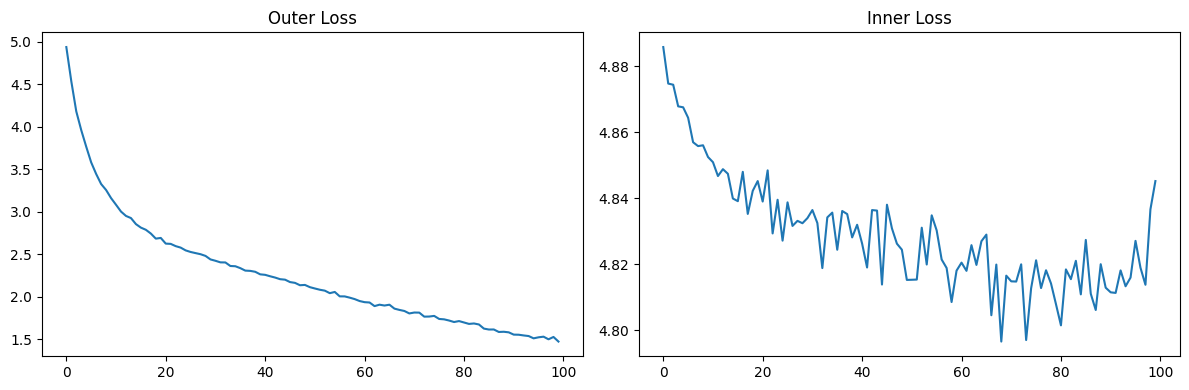

In [8]:
config = GPT2Config.from_pretrained('gpt2')
config.n_layer = 4
config.n_head = 4
config.n_embd = 128
config.vocab_size = 128
config.pad_token_id = tokenizer.convert_tokens_to_ids('[PAD]')
config.bos_token_id = tokenizer.convert_tokens_to_ids('[BOS]')
config.eos_token_id = tokenizer.convert_tokens_to_ids('[EOS]')

model = GradMemGPT(config=config, n_mem_tokens=8, K=1, lr=0.01, use_adam=True, grad_mode="none")
model = model.to('cuda')

from torch.optim import Adam

optimizer = Adam(model.parameters(), lr=1e-04)
out_losses = []
inner_losses = []
for i in tqdm(range(100)):
    batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
    batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
    batch['labels'] = batch['labels'].to('cuda')
    outputs = model(**batch)
    loss = outputs['loss']
    if torch.isnan(loss):
        raise ValueError(f"NaN at step {i}")
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    out_losses.append(loss.item())
    inner_losses.append(outputs['inner_loss'].item())

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(out_losses)
ax1.set_title('Outer Loss')
ax2.plot(inner_losses)
ax2.set_title('Inner Loss')
plt.tight_layout()
plt.show()

100%|██████████| 100/100 [00:01<00:00, 74.59it/s]


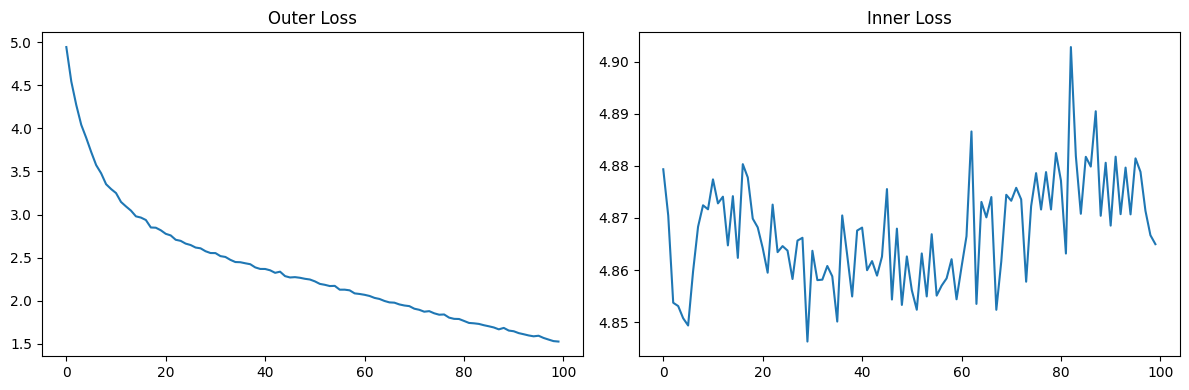

In [9]:
config = GPT2Config.from_pretrained('gpt2')
config.n_layer = 4
config.n_head = 4
config.n_embd = 128
config.vocab_size = 128
config.pad_token_id = tokenizer.convert_tokens_to_ids('[PAD]')
config.bos_token_id = tokenizer.convert_tokens_to_ids('[BOS]')
config.eos_token_id = tokenizer.convert_tokens_to_ids('[EOS]')

model = GradMemGPT(config=config, n_mem_tokens=8, K=1, lr=0.01, use_adam=True, grad_mode="first")
model = model.to('cuda')

from torch.optim import Adam

optimizer = Adam(model.parameters(), lr=1e-04)
out_losses = []
inner_losses = []
for i in tqdm(range(100)):
    batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
    batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
    batch['labels'] = batch['labels'].to('cuda')
    outputs = model(**batch)
    loss = outputs['loss']
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    out_losses.append(loss.item())
    inner_losses.append(outputs['inner_loss'].item())

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(out_losses)
ax1.set_title('Outer Loss')
ax2.plot(inner_losses)
ax2.set_title('Inner Loss')
plt.tight_layout()
plt.show()

 15%|█▌        | 15/100 [00:00<00:01, 70.41it/s]

100%|██████████| 100/100 [00:01<00:00, 70.94it/s]


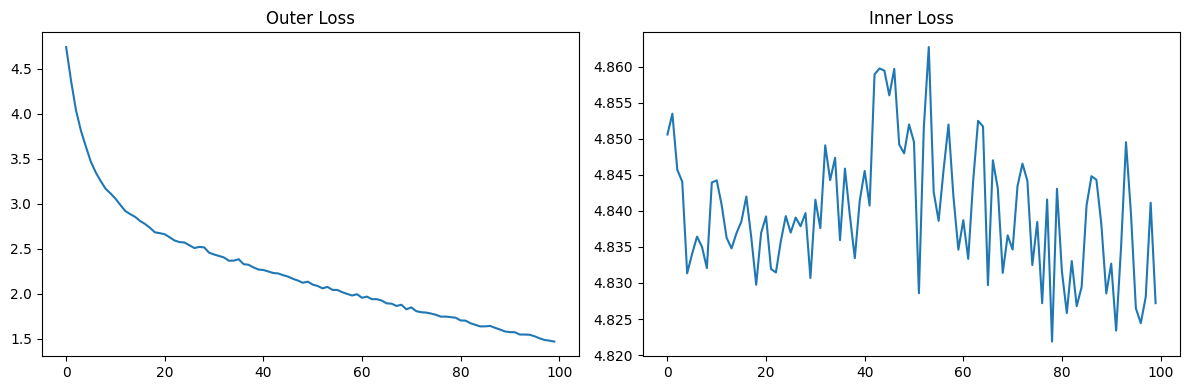

In [10]:
config = GPT2Config.from_pretrained('gpt2')
config.n_layer = 4
config.n_head = 4
config.n_embd = 128
config.vocab_size = 128
config.pad_token_id = tokenizer.convert_tokens_to_ids('[PAD]')
config.bos_token_id = tokenizer.convert_tokens_to_ids('[BOS]')
config.eos_token_id = tokenizer.convert_tokens_to_ids('[EOS]')

model = GradMemGPT(config=config, n_mem_tokens=8, K=1, lr=0.01, use_adam=True, grad_mode="second")
model = model.to('cuda')

from torch.optim import Adam

optimizer = Adam(model.parameters(), lr=1e-04)
out_losses = []
inner_losses = []
for i in tqdm(range(100)):
    batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
    batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
    batch['labels'] = batch['labels'].to('cuda')
    outputs = model(**batch)
    loss = outputs['loss']
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    out_losses.append(loss.item())
    inner_losses.append(outputs['inner_loss'].item())

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(out_losses)
ax1.set_title('Outer Loss')
ax2.plot(inner_losses)
ax2.set_title('Inner Loss')
plt.tight_layout()
plt.show()

  9%|▉         | 9/100 [00:00<00:02, 40.34it/s]

100%|██████████| 100/100 [00:02<00:00, 41.91it/s]


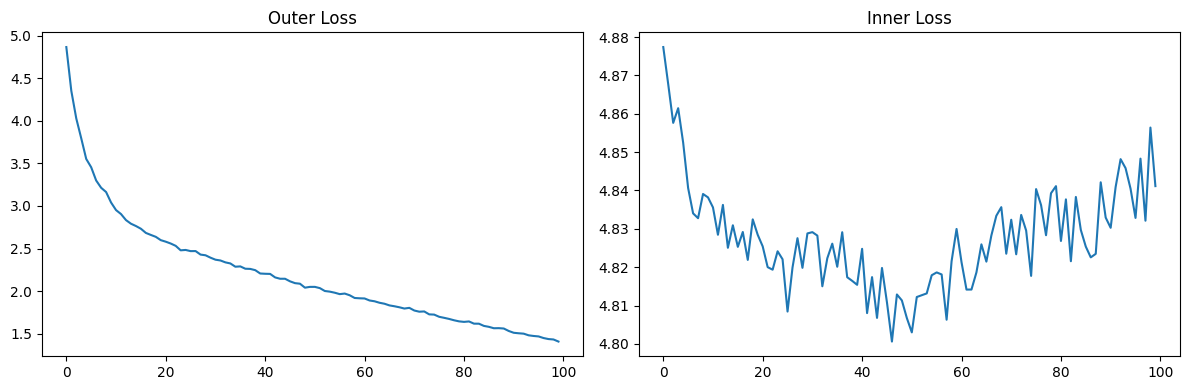

In [11]:
config = GPT2Config.from_pretrained('gpt2')
config.n_layer = 4
config.n_head = 4
config.n_embd = 128
config.vocab_size = 128
config.pad_token_id = tokenizer.convert_tokens_to_ids('[PAD]')
config.bos_token_id = tokenizer.convert_tokens_to_ids('[BOS]')
config.eos_token_id = tokenizer.convert_tokens_to_ids('[EOS]')

model = GradMemGPT(config=config, n_mem_tokens=8, K=1, lr=0.01, use_adam=False, grad_mode="second")
model = model.to('cuda')

from torch.optim import Adam

optimizer = Adam(model.parameters(), lr=1e-04)
out_losses = []
inner_losses = []
for i in tqdm(range(100)):
    batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
    batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
    batch['labels'] = batch['labels'].to('cuda')
    outputs = model(**batch)
    loss = outputs['loss']
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    out_losses.append(loss.item())
    inner_losses.append(outputs['inner_loss'].item())

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(out_losses)
ax1.set_title('Outer Loss')
ax2.plot(inner_losses)
ax2.set_title('Inner Loss')
plt.tight_layout()
plt.show()